In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
import kaleido

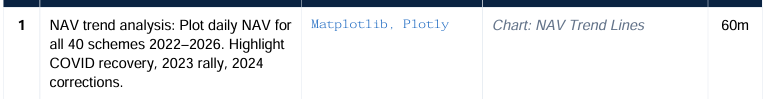

In [3]:
from pathlib import Path
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORT_DIR= BASE_DIR/"reports"
nav_df = pd.read_csv(PROCESSED_DIR / "nav_history_clean.csv")

In [4]:
nav_df['date']=pd.to_datetime(nav_df['date'])

In [5]:
nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016.0,520.4608
1,2022-01-04,100016.0,515.0971
2,2022-01-05,100016.0,521.7239
3,2022-01-06,100016.0,515.7880
4,2022-01-07,100016.0,515.1639


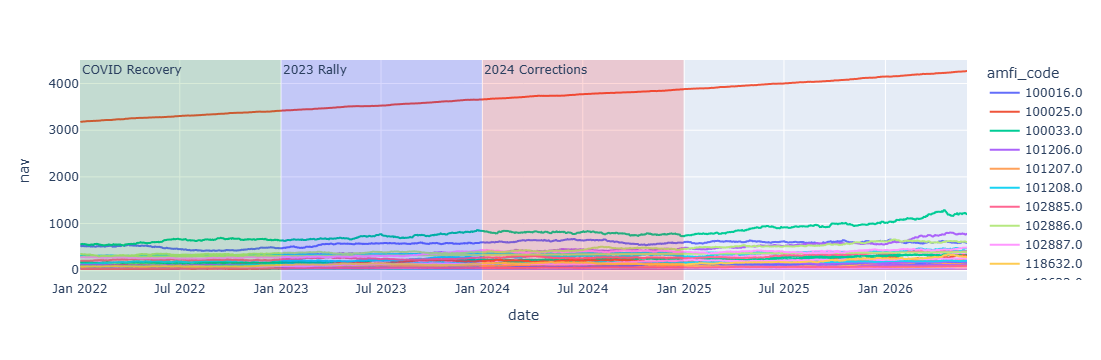

In [6]:
fig=px.line(nav_df,x='date',y='nav',color='amfi_code')

fig.add_vrect(
    x0="2022-01-01",
    x1="2022-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="COVID Recovery",
    annotation_position="top left"
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="blue",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Rally",
    annotation_position="top left"
)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Corrections",
    annotation_position="top left"
)
fig.show()

In [7]:
fig.write_image(REPORT_DIR/'nav_trend.png')

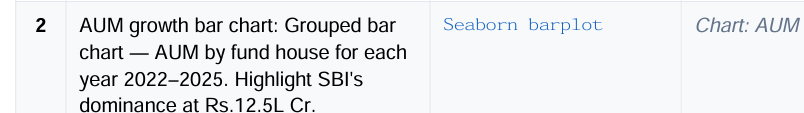

In [8]:
aum_df = pd.read_csv(PROCESSED_DIR / "aum_by_fund_house_clean.csv")

In [9]:
aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

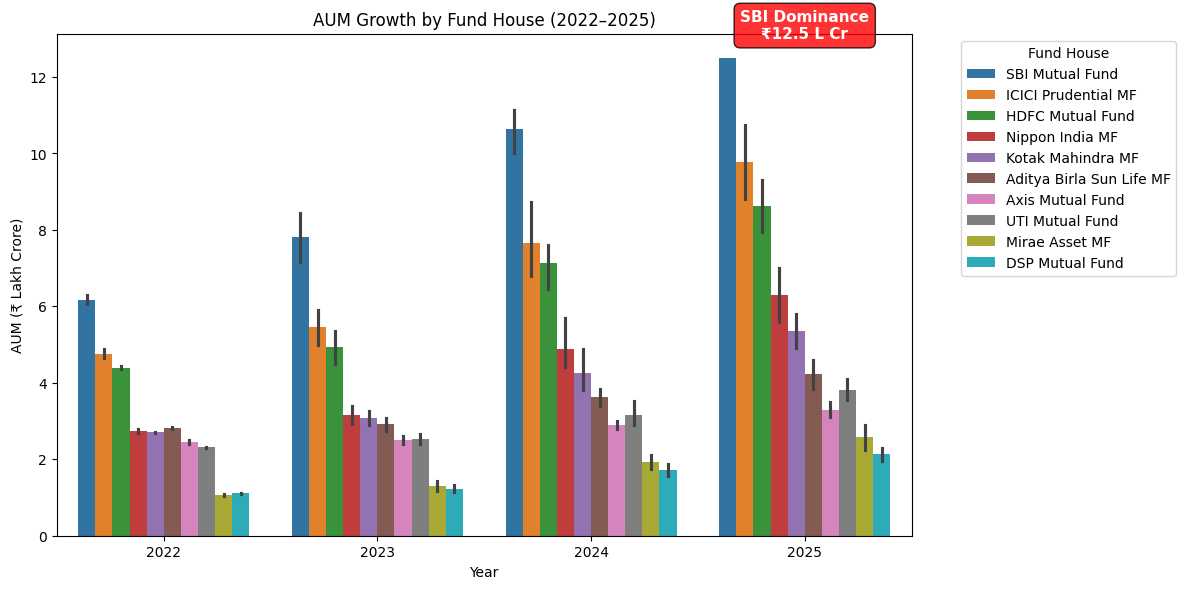

In [15]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=aum_df[aum_df["year"].between(2022, 2025)],
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

sbi = aum_df[
    (aum_df["fund_house"] == "SBI Mutual Fund") &
    (aum_df["year"] == 2025)
]
value = sbi["aum_lakh_crore"].iloc[0]
plt.text(3,value + 0.5,"SBI Dominance\n₹12.5 L Cr",ha="center",fontsize=11,fontweight="bold",color="white",bbox=dict(
    facecolor="red",alpha=0.8,boxstyle="round,pad=0.4"))

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(REPORT_DIR/"aum_growth_chart.png")
plt.show()

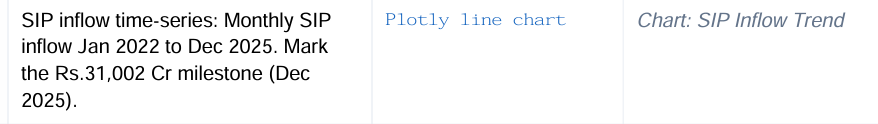

In [16]:
SIP_df = pd.read_csv(PROCESSED_DIR / "monthly_sip_inflows_clean.csv")

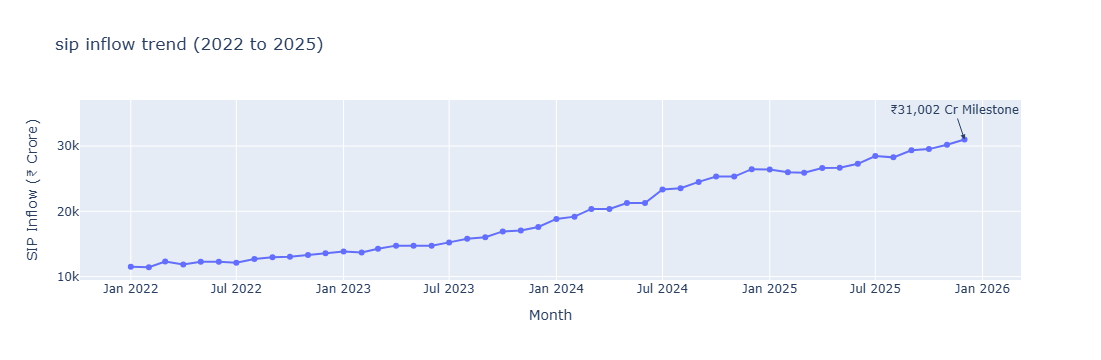

In [26]:
SIP_df["month"] = pd.to_datetime(SIP_df["month"])
SIP_df = SIP_df.sort_values("month")

fig = px.line(
    SIP_df,
    x="month",
    y="sip_inflow_crore",
    title="sip inflow trend (2022 to 2025)",
    markers=True
)

milestone = SIP_df[SIP_df["month"] == pd.Timestamp("2025-12-01")]
value = milestone["sip_inflow_crore"].iloc[0]

fig.add_annotation(
    x="2025-12-01",
    y=value,
    text="₹31,002 Cr Milestone",
    showarrow=True,
    arrowhead=2,
    font=dict(size=12))
fig.update_layout(xaxis_title="Month",yaxis_title="SIP Inflow (₹ Crore)")

fig.write_image(REPORT_DIR / "sip_inflow_trend.png", scale=3)

fig.show()

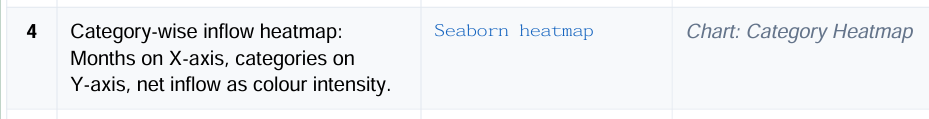

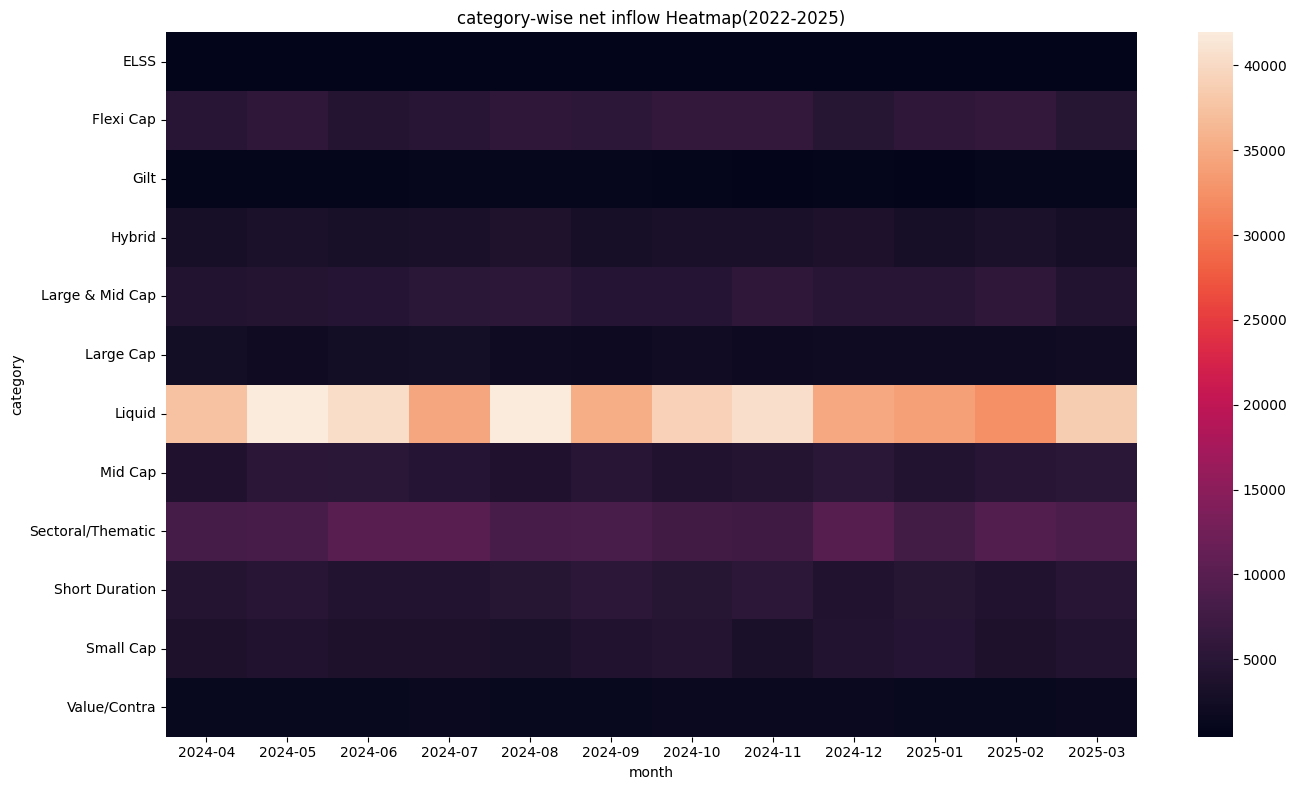

In [35]:
cat_df = pd.read_csv(PROCESSED_DIR / "category_inflows_clean.csv")
heatmap_data = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data)
plt.title("category-wise net inflow Heatmap(2022-2025)")
plt.xlabel("month")
plt.ylabel("category")
plt.tight_layout()
plt.savefig(REPORT_DIR / "category_heatmap.png")
plt.show()

In [36]:
inv_df = pd.read_csv(PROCESSED_DIR / "investor_transactions_clean.csv")

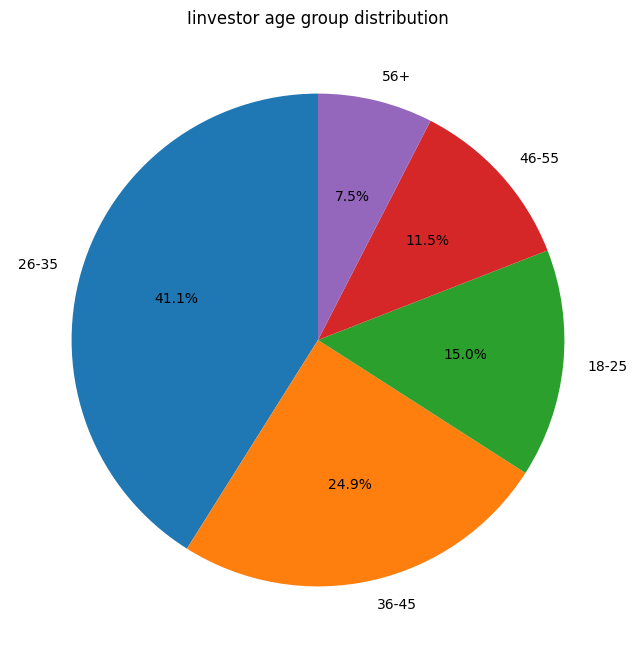

In [37]:
age_counts = inv_df["age_group"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Iinvestor age group distribution")
plt.savefig(REPORT_DIR / "age_group_distribution.png",)
plt.show()

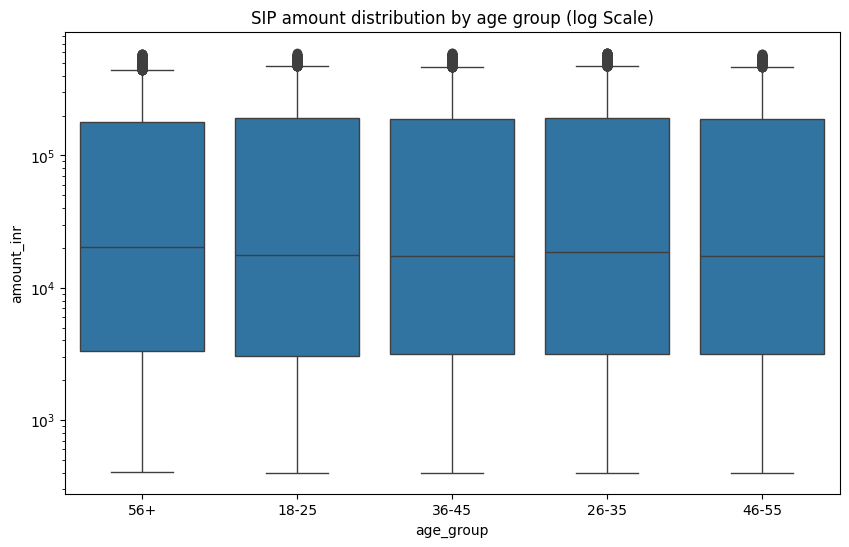

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=inv_df,
    x="age_group",
    y="amount_inr"
)
plt.yscale("log")
plt.title("SIP amount distribution by age group (log Scale)")
plt.savefig(REPORT_DIR / "sip_amount_boxplot.png",)
plt.show()

In [41]:
inv_df = pd.read_csv(PROCESSED_DIR / "investor_transactions_clean.csv")

In [42]:
state_sip =inv_df.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

In [58]:
state_sip

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

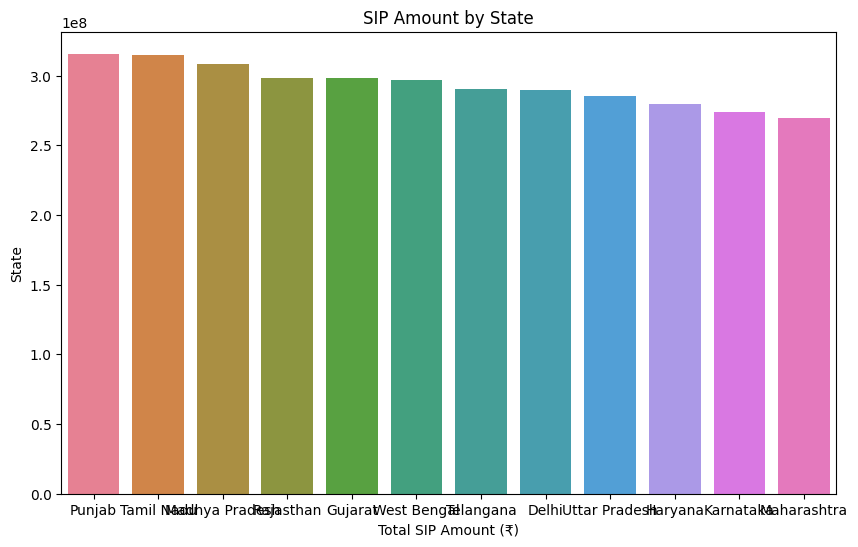

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(y=state_sip.values,x=state_sip.index,hue=state_sip.index)
plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.savefig(REPORT_DIR / "horizontal_bar_chart.png")
plt.show()

In [45]:
print(inv_df["city_tier"].value_counts())

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


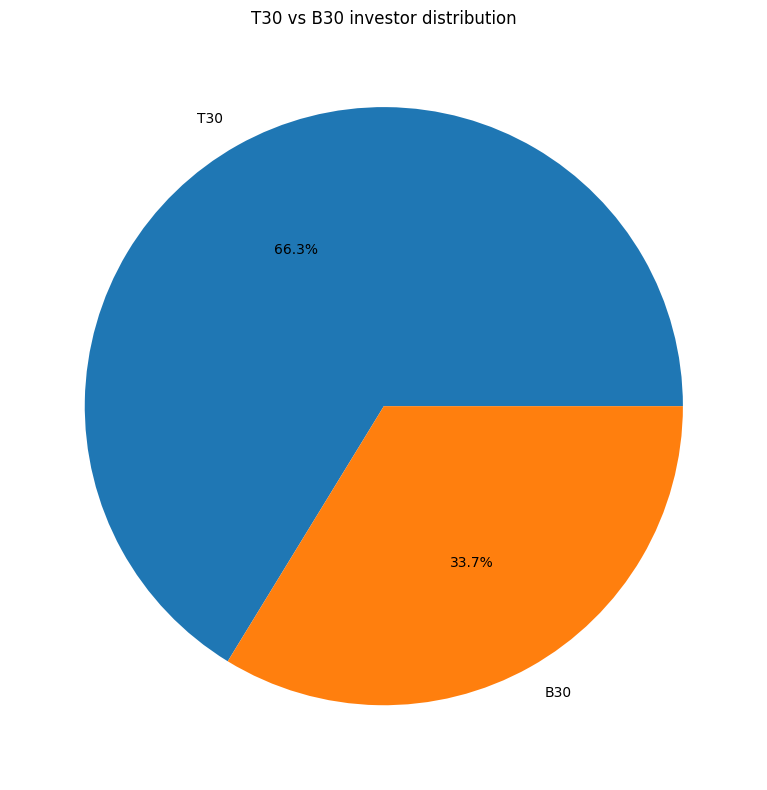

In [64]:
tier_counts = inv_df["city_tier"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(tier_counts,labels=tier_counts.index,autopct="%1.1f%%")
plt.title("T30 vs B30 investor distribution")
plt.tight_layout()
plt.savefig(REPORT_DIR / "t30_vs_b30_pie.png")
plt.show()

In [65]:
folio_df = pd.read_csv(PROCESSED_DIR / "industry_folio_count_clean.csv")
print(folio_df.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


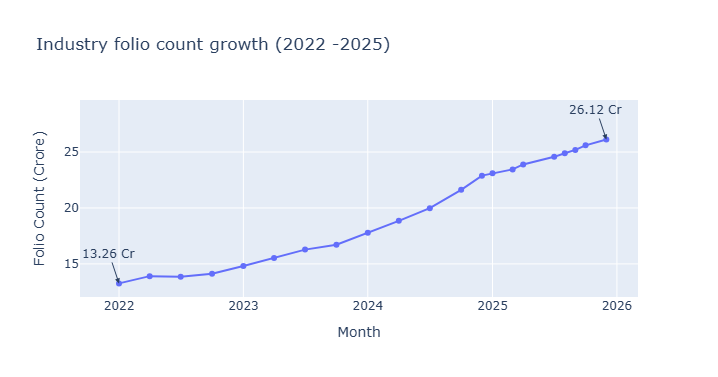

In [68]:
folio_df["month"] = pd.to_datetime(folio_df["month"])
folio_df = folio_df.sort_values("month")
fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry folio count growth (2022 -2025)"
)
start_row = folio_df.iloc[0]

fig.add_annotation(
    x=str(start_row["month"].date()),
    y=float(start_row["total_folios_crore"]),
    text="13.26 Cr",
    showarrow=True,
    arrowhead=2
)

end_row = folio_df.iloc[-1]
fig.add_annotation(
    x=str(end_row["month"].date()),
    y=float(end_row["total_folios_crore"]),
    text="26.12 Cr",
    showarrow=True,
    arrowhead=2
)
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Folio Count (Crore)"
)
fig.write_image(REPORT_DIR / "folio_count_growth.png")
fig.show()

In [71]:
nav_df = pd.read_csv(PROCESSED_DIR / "nav_history_clean.csv")
nav_df.columns

Index(['date', 'amfi_code', 'nav'], dtype='object')

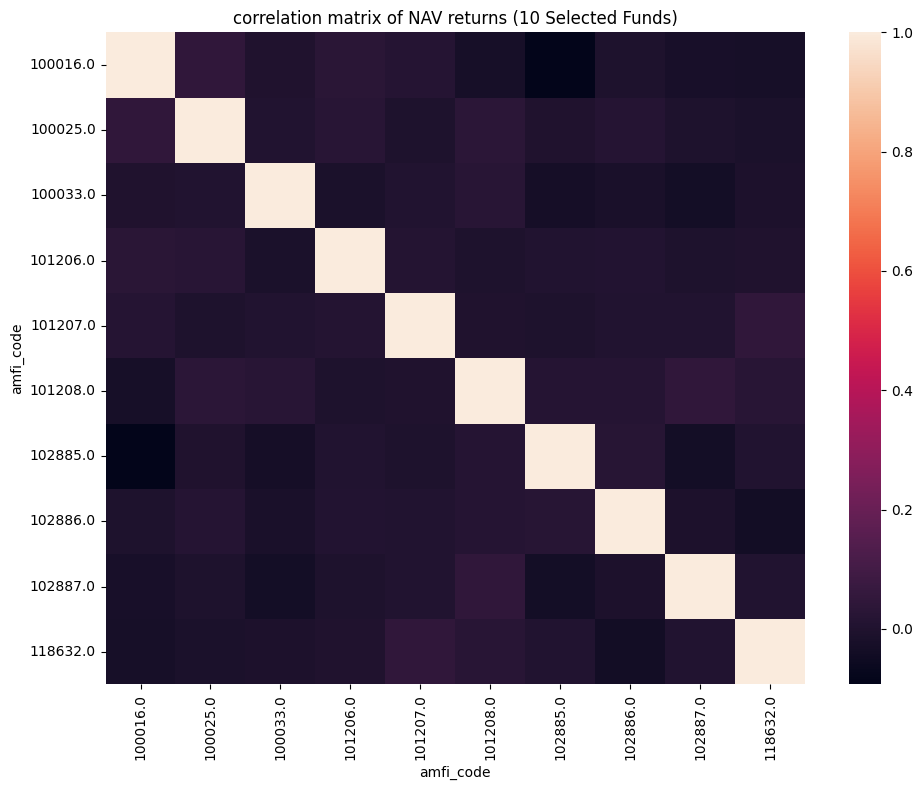

In [73]:
nav_df["daily_return"] = (nav_df.groupby("amfi_code")["nav"].pct_change())
selected_funds = nav_df["amfi_code"].unique()[:10]
nav_10 = nav_df[nav_df["amfi_code"].isin(selected_funds)]
returns_matrix = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)
corr_matrix = returns_matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=False)
plt.title("correlation matrix of NAV returns (10 Selected Funds)")
plt.tight_layout()
plt.savefig(REPORT_DIR / "correlation_matrix.png")
plt.show()

In [74]:
holdings_df = pd.read_csv(PROCESSED_DIR / "portfolio_holdings_clean.csv")

In [82]:
sector_weights = (holdings_df.groupby("sector")["weight_pct"].sum().sort_values(ascending=False))
sector_weights = sector_weights.head(10)
sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

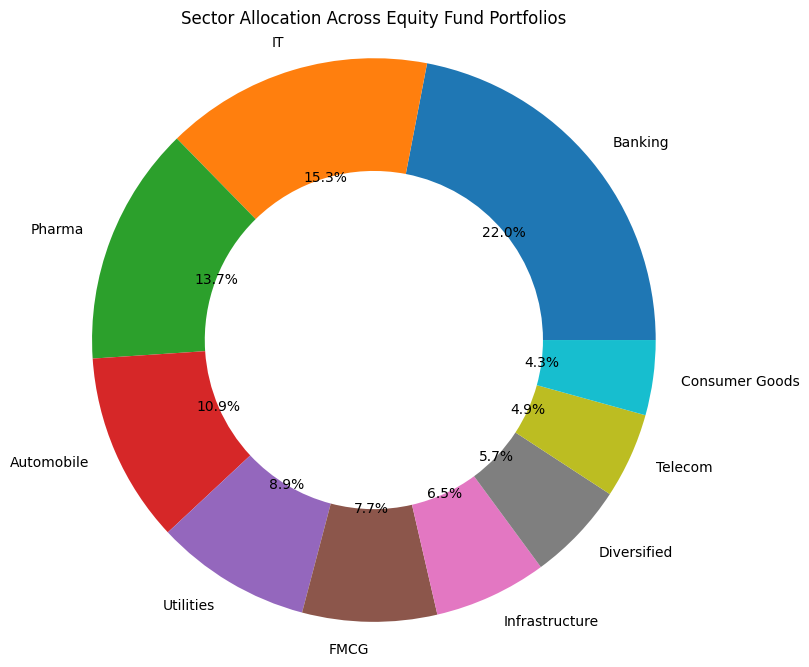

In [83]:
plt.figure(figsize=(8, 8))
plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4}
)
plt.title("Sector Allocation Across Equity Fund Portfolios")
plt.axis("equal")
plt.savefig(REPORT_DIR / "sector_allocation_donut.png")
plt.show()